#  Estimation d'âge apparent par classification ordinale — APPA-real

Backbone : SE-ResNeXt50-32x4d pré-entraîné ImageNet  
Dataset : APPA-real — 7 591 images (4 113 train / 1 500 valid / 1 978 test)  
Métrique : MAE (Mean Absolute Error) en années  
Référence humaine : 4.5 ans (désaccord inter-annotateurs)

---

L'âge apparent est une perception subjective : sur APPA-real, chaque image est notée par des dizaines d'annotateurs et la variance inter-annotateurs peut atteindre ±4 ans. Deux conséquences directes pour la modélisation.

D'abord, la cible est intrinsèquement floue. Prédire "34 ans" pour une image notée 34.7 en moyenne est arbitraire, et une distribution de probabilité centrée sur 34.7 est plus honnête qu'un label discret.

Ensuite, la régression directe est instable. Un modèle qui n'apprend pas converge vers la moyenne du dataset (environ 30 ans sur APPA-real) par minimisation naïve du MAE.

La solution adoptée dans ce notebook : classification sur 101 bins (un par année entière de 0 à 100), avec prédiction finale par espérance de la distribution softmax :

$$\hat{a} = \sum_{k=0}^{100} k \cdot \text{softmax}(\text{logit}_k)$$

Cette espérance est une valeur continue (ex. 34.7 ans), contrairement à un argmax qui forcerait des prédictions entières. On explore successivement trois formulations de la loss — Label Smoothing, Mean-Variance et CORAL — sur le même backbone SE-ResNeXt50.

## 0. Setup de l'environnement

In [1]:
# ============================================================
# Setup global — compatible Local (macOS) et Google Colab
# ============================================================
import os, sys, gc, math, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
warnings.filterwarnings('ignore')

# ── Détection de l'environnement ──────────────────────────────────────────────
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive

    # ⚠️  Monter Drive EN PREMIER et vérifier la connexion avant tout import cv2.
    # Sans ça, le hook Colab sur cv2 essaie d'accéder à Drive et plante
    # avec OSError 107 "Transport endpoint is not connected".
    def _mount_drive(force=False):
        drive.mount('/content/drive', force_remount=force)
        # Vérification : le point de montage doit être accessible
        test = Path('/content/drive/MyDrive')
        for _ in range(10):
            try:
                _ = list(test.iterdir())
                return True
            except OSError:
                time.sleep(2)
        return False

    if not _mount_drive(force=False):
        print("⚠️  Drive non accessible, remontage forcé...")
        _mount_drive(force=True)

    PROJECT_DIR = Path('/content/drive/MyDrive/Deep-learning-project')
    os.chdir(PROJECT_DIR)
else:
    PROJECT_DIR = Path('/Users/louisduvignacq/Desktop/X/3A/Deep learning/Deep-learning-project')
    os.chdir(PROJECT_DIR)

sys.path.insert(0, str(PROJECT_DIR))
print(f"Environnement : {'Google Colab' if IN_COLAB else 'Local macOS'}")
print(f"PROJECT_DIR   : {PROJECT_DIR}")
assert PROJECT_DIR.exists(), f"PROJECT_DIR introuvable : {PROJECT_DIR}"

# ── GPU ───────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device        : {str(device).upper()}")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    print(f"GPU           : {torch.cuda.get_device_name(0)}")
    print(f"VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} Go")

Mounted at /content/drive
Environnement : Google Colab
PROJECT_DIR   : /content/drive/MyDrive/Deep-learning-project
Device        : CUDA
GPU           : NVIDIA H100 80GB HBM3
VRAM          : 79.2 Go


In [2]:
# ── Installation des dépendances ──────────────────────────────────────────────
import subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "pretrainedmodels", "albumentations", "opencv-python",
                "seaborn", "scikit-learn"], check=True)
print("Dépendances prêtes.")

Dépendances prêtes.


## 1. Chargement du dataset APPA-real


In [3]:
# ── Extraction du dataset (Colab uniquement) ──────────────────────────────────
if IN_COLAB:
    import zipfile, time
    from google.colab import drive

    zip_path   = '/content/drive/MyDrive/appa-real-release.zip'
    local_zip  = '/content/appa-real-release.zip'
    local_data = Path('/content/appa-real-release')

    if not Path(zip_path).exists():
        print(f"❌ Fichier non trouvé : {zip_path}")
        print("   Uploadez appa-real-release.zip dans 'Mon Drive'.")
    else:
        if not local_data.exists():
            print("📦 Copie du zip depuis Drive vers /content/ ...")

            # Copie robuste chunk par chunk (évite OSError 107 sur Drive monté)
            CHUNK = 8 * 1024 * 1024   # 8 Mo par chunk
            for attempt in range(1, 4):
                try:
                    written = 0
                    with open(zip_path, 'rb') as src, open(local_zip, 'wb') as dst:
                        while True:
                            chunk = src.read(CHUNK)
                            if not chunk:
                                break
                            dst.write(chunk)
                            written += len(chunk)
                    print(f"   ✓ Copie réussie ({written / 1024**3:.2f} Go)")
                    break
                except OSError as e:
                    print(f"   ⚠️  Tentative {attempt}/3 échouée ({e}), reconnexion Drive...")
                    drive.mount('/content/drive', force_remount=True)
                    time.sleep(5)
                    if Path(local_zip).exists():
                        Path(local_zip).unlink()
            else:
                raise RuntimeError("Copie échouée après 3 tentatives. Relancez la cellule.")

            print("📂 Extraction en cours ...")
            with zipfile.ZipFile(local_zip, 'r') as z:
                z.extractall('/content/')
            Path(local_zip).unlink()
            macosx = Path('/content/__MACOSX')
            if macosx.exists():
                import shutil; shutil.rmtree(macosx)
            print("✅ Dataset extrait dans /content/appa-real-release/")
        else:
            print("✅ Dataset déjà présent (skip extraction)")

        DATA_ROOT = local_data
        for split in ["train", "valid", "test"]:
            d = local_data / split
            n = len([f for f in d.iterdir() if f.suffix == ".jpg" and "_face" not in f.name]) if d.exists() else 0
            print(f"   {split:6s} : {n} images .jpg")
        print(f"\nDATA_ROOT → {DATA_ROOT}")
else:
    DATA_ROOT = PROJECT_DIR / "appa-real-release"
    assert DATA_ROOT.exists(), "Dossier appa-real-release manquant !"
    print(f"DATA_ROOT local : {DATA_ROOT}")

📦 Copie du zip depuis Drive vers /content/ ...
   ✓ Copie réussie (0.83 Go)
📂 Extraction en cours ...
✅ Dataset extrait dans /content/appa-real-release/
   train  : 4113 images .jpg
   valid  : 1500 images .jpg
   test   : 1978 images .jpg

DATA_ROOT → /content/appa-real-release


## Partie 1 — Label Smoothing Gaussien (version naïve, σ = 1.5)

### Principe

Au lieu d'un label *one-hot* où seul le bin de l'âge entier arrondi vaut 1, on construit une distribution gaussienne centrée sur l'âge apparent moyen $\mu$ (valeur continue, non arrondie) :

$$y_k = \frac{1}{Z} \exp\!\left(-\frac{(k - \mu)^2}{2\sigma^2}\right), \quad k \in \{0, \ldots, 100\}$$

La loss est une cross-entropie pondérée entre cette distribution cible et le softmax prédit — équivalente à une divergence KL :

$$\mathcal{L} = -\sum_{k=0}^{100} y_k \log p_k$$


In [ ]:
class OrdinalLabelSmoothing(nn.Module):
    """
    Label smoothing gaussien pour classification d'âge apparent.
    La distribution cible est une gaussienne N(age, sigma).

    Accepte des targets FLOAT (apparent_age_avg non arrondi),
    ce qui évite l'erreur d'arrondi sur des âges comme 34.7 → 35.

    Args:
        num_classes : nombre de bins (101 pour 0-100 ans)
        sigma       : écart-type de la gaussienne (en années)
    """
    def __init__(self, num_classes: int = 101, sigma: float = 1.5):
        super().__init__()
        self.K     = num_classes
        self.sigma = sigma

    def _smooth_labels(self, targets: torch.Tensor) -> torch.Tensor:
        bins   = torch.arange(self.K, device=targets.device).float()   # (K,)
        diff   = bins.unsqueeze(0) - targets.float().unsqueeze(1)       # (B, K)
        labels = torch.exp(-0.5 * (diff / self.sigma) ** 2)
        return labels / labels.sum(dim=1, keepdim=True)                 # (B, K) normalisé

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        log_probs     = F.log_softmax(logits, dim=-1)
        smooth_labels = self._smooth_labels(targets)
        return -(smooth_labels * log_probs).sum(dim=-1).mean()

La cellule suivante visualise la distribution cible pour σ = 1.5 et σ = 3.0, et calcule l'entropie de chaque configuration pour quantifier le degré de lissage.

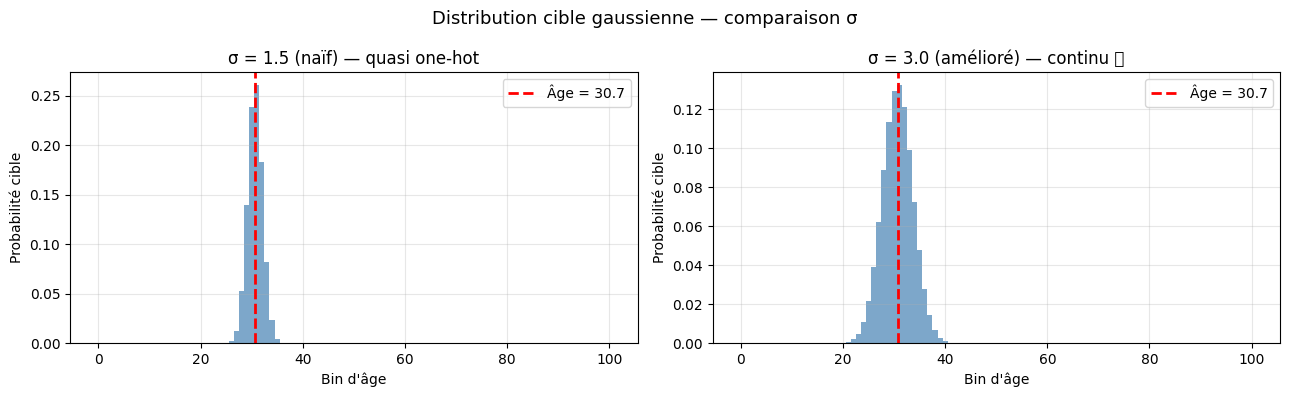


Ablation des valeurs de σ :
    σ | Entropie cible | Comportement
------------------------------------------------------------
  0.5 |         0.6701 | Quasi one-hot, prédictions entières
  1.5 |         1.8244 | Prédictions semi-entières, MAE ~8–9 ans
  3.0 |         2.5176 | Prédictions continues ✅  (choix retenu)
  5.0 |         3.0282 | Distribution trop plate, signal faible


In [5]:
# ── Visualisation des distributions cibles σ = 1.5 et σ = 3.0 ────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, sigma, title in zip(axes, [1.5, 3.0],
                             ["σ = 1.5 (naïf) — quasi one-hot",
                              "σ = 3.0 (amélioré) — continu ✅"]):
    crit   = OrdinalLabelSmoothing(101, sigma=sigma)
    sample = torch.tensor([30.7])
    smooth = crit._smooth_labels(sample).squeeze().numpy()
    ax.bar(range(101), smooth, color='steelblue', alpha=0.7, width=1.0)
    ax.axvline(x=30.7, color='red', linestyle='--', linewidth=2, label='Âge = 30.7')
    ax.set_title(title)
    ax.set_xlabel("Bin d'âge")
    ax.set_ylabel("Probabilité cible")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Distribution cible gaussienne — comparaison σ", fontsize=13)
plt.tight_layout()
plt.show()

# Ablation σ : entropie de la distribution cible
print("\nAblation des valeurs de σ :")
print(f"{'σ':>5} | {'Entropie cible':>14} | {'Comportement'}")
print("-" * 60)
targets_test = torch.randint(15, 70, (200,)).float()
comportements = {
    0.5: "Quasi one-hot, prédictions entières",
    1.5: "Prédictions semi-entières, MAE ~8–9 ans",
    3.0: "Prédictions continues ✅  (choix retenu)",
    5.0: "Distribution trop plate, signal faible"
}
for sigma in [0.5, 1.5, 3.0, 5.0]:
    crit    = OrdinalLabelSmoothing(101, sigma=sigma)
    smooth  = crit._smooth_labels(targets_test)
    entropy = -(smooth * smooth.clamp(min=1e-8).log()).sum(dim=-1).mean().item()
    print(f"{sigma:>5.1f} | {entropy:>14.4f} | {comportements[sigma]}")

### Architecture

Le pipeline est le suivant :

```
Image 224×224×3
      │
      ▼
SE-ResNeXt50-32x4d
      │  (B, 2048, 1, 1)
      ▼
nn.Flatten(1)   
      │  (B, 2048)
      ▼
BatchNorm1d(2048)
      │
      ▼
Linear(2048→256) → BN → ReLU → Dropout(0.3) → Linear(256→101)
      │  (B, 101 logits)
      ▼
Softmax expectation → âge prédit ∈ ℝ
```

Pour la prédiction, on utilise l'espérance de la distribution plutôt qu'un argmax. La valeur $\hat{a} = \sum_k k \cdot \text{softmax}(\text{logit}_k)$ est continue et exploite toute la forme de la distribution, pas seulement son pic.

In [ ]:
class AppAgeHead(nn.Module):
    """
    Tête de classification ordinale pour APPA-real.
    Retourne 101 logits (un par bin d'âge).
    La prédiction finale est l'espérance de la distribution softmax.
    """
    def __init__(self, embed_dim: int, num_classes: int = 101, dropout: float = 0.3):
        super().__init__()
        self.bins = torch.arange(num_classes).float()  # [0, 1, ..., 100]
        self.head = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, embeddings: torch.Tensor) -> torch.Tensor:
        return self.head(embeddings)   # (B, 101) logits bruts

    def predict_age(self, logits: torch.Tensor) -> torch.Tensor:
        """Softmax expectation : E[age] = Σ k · softmax(logit_k)"""
        bins  = self.bins.to(logits.device)
        probs = F.softmax(logits, dim=-1)   # (B, K)
        return (probs * bins).sum(dim=-1)   # (B,) âge continu prédit


class AppaRealModel(nn.Module):
    """
    Backbone SE-ResNeXt50 → Flatten → BN → AppAgeHead
    """
    def __init__(self, backbone: nn.Module, embed_dim: int,
                 num_classes: int = 101, dropout: float = 0.3):
        super().__init__()
        self.backbone = backbone
        self.flatten  = nn.Flatten(1)               # (B,2048,1,1) → (B,2048)
        self.bn       = nn.BatchNorm1d(embed_dim)
        self.head     = AppAgeHead(embed_dim, num_classes, dropout)

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        features   = self.backbone(images)          # (B, 2048, 1, 1)
        features   = self.flatten(features)         # (B, 2048) garanti
        embeddings = self.bn(features)
        return self.head(embeddings)                # (B, 101)

    def predict(self, images: torch.Tensor) -> torch.Tensor:
        return self.head.predict_age(self.forward(images))  # (B,) âge continu

### Dataset — version naïve (images complètes, σ = 1.5, batch 32)

In [7]:
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

class AgeDataset(Dataset):
    """
    Dataset APPA-real.
    Retourne : (image, age_class, age_float, real_age, std)
    use_face_crop : si True, utilise le crop _face.jpg quand disponible
    """
    def __init__(self, csv_path, img_dir, transform=None,
                 num_classes=101, use_face_crop=False):
        self.img_dir      = Path(img_dir).resolve()
        self.transform    = transform
        self.num_classes  = num_classes
        self.use_face_crop = use_face_crop

        df = pd.read_csv(csv_path)
        df = df[df["file_name"].apply(
            lambda x: (self.img_dir / x).exists()
        )].reset_index(drop=True)
        self.df      = df
        self.age_col = "apparent_age_avg" if "apparent_age_avg" in df.columns else "apparent_age"

        n_face = df["file_name"].apply(
            lambda x: (self.img_dir / (x + "_face.jpg")).exists()
        ).sum()
        print(f"   {self.img_dir.name} : {len(df)} images "
              f"({'face crop activé' if use_face_crop else 'images complètes'}, "
              f"{n_face} crops dispo)")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        age      = float(row[self.age_col])
        real_age = float(row["real_age"]) if "real_age" in self.df.columns else age
        std      = float(row["apparent_age_std"]) if "apparent_age_std" in self.df.columns else 2.0

        if self.use_face_crop:
            face_path = self.img_dir / (row["file_name"] + "_face.jpg")
            full_path = self.img_dir / row["file_name"]
            img_path  = face_path if face_path.exists() else full_path
        else:
            img_path = self.img_dir / row["file_name"]

        img = cv2.imread(str(img_path))
        if img is None:
            img = np.zeros((224, 224, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            img = self.transform(image=img)["image"]

        age_class = max(0, min(self.num_classes - 1, int(round(age))))
        return img, age_class, age, real_age, std

In [8]:
# ── Transforms version naïve (images complètes, augmentations légères) ────────
train_transform_v1 = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Affine(translate_percent=0.05, scale=(0.95, 1.05), rotate=(-15, 15), p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])
valid_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

CSV_ROOT   = PROJECT_DIR / "appa-real-release"
NUM_CLASSES = 101
NUM_WORKERS = 2 if IN_COLAB else 0
PIN_MEMORY  = IN_COLAB

print("Chargement APPA-REAL — version naïve (images complètes, batch=32) :")
train_ds_v1 = AgeDataset(CSV_ROOT / "gt_avg_train.csv", DATA_ROOT / "train",
                          train_transform_v1, use_face_crop=False)
valid_ds_v1 = AgeDataset(CSV_ROOT / "gt_avg_valid.csv", DATA_ROOT / "valid",
                          valid_transform, use_face_crop=False)
test_ds_v1  = AgeDataset(CSV_ROOT / "gt_avg_test.csv",  DATA_ROOT / "test",
                          valid_transform, use_face_crop=False)

BATCH_SIZE_V1 = 32
train_loader_v1 = DataLoader(train_ds_v1, batch_size=BATCH_SIZE_V1, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
valid_loader_v1 = DataLoader(valid_ds_v1, batch_size=BATCH_SIZE_V1, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader_v1  = DataLoader(test_ds_v1,  batch_size=BATCH_SIZE_V1, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
print(f"Train : {len(train_ds_v1)} | Valid : {len(valid_ds_v1)} | Test : {len(test_ds_v1)}")

Chargement APPA-REAL — version naïve (images complètes, batch=32) :
   train : 4113 images (images complètes, 4113 crops dispo)
   valid : 1500 images (images complètes, 1500 crops dispo)
   test : 1978 images (images complètes, 1978 crops dispo)
Train : 4113 | Valid : 1500 | Test : 1978


### Stratégie d'entraînement

Le backbone SE-ResNeXt50 est pré-entraîné sur ImageNet avec 25 millions de paramètres.

Les 5 premières epochs s'effectuent avec le backbone gelé : seules la tête et la BatchNorm apprennent. Cela permet d'initialiser correctement la tête avant d'introduire des gradients dans le backbone. À partir de l'epoch 6, le backbone est dégelé avec un lr 10× plus petit (1e-5 contre 1e-4 pour la tête) pour s'adapter progressivement sans perdre ses représentations.

| Phase | Epochs | Backbone | lr backbone | lr tête |
|-------|--------|----------|-------------|---------|
| Warmup | 1–5 | gelé | — | 1e-4 |
| Fine-tuning | 6–30 | dégelé | 1e-5 | 1e-4 |

Le scheduler `CosineAnnealingLR` avec `eta_min=1e-6` fait décroître le lr en cosinus sans jamais l'annuler complètement, ce qui évite la stagnation en fin d'entraînement.

In [ ]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_mae, n = 0.0, 0.0, 0
    for imgs, age_class, age_float, real_age, std in loader:
        imgs      = imgs.to(device, non_blocking=True)
        age_float = age_float.to(device, dtype=torch.float32)
        optimizer.zero_grad()
        logits = model(imgs)                                     # (B, 101)
        loss   = criterion(logits, age_float)                   # cible float
        loss.backward()
        optimizer.step()
        with torch.no_grad():
            mae = (model.head.predict_age(logits) - age_float).abs().sum()
        bs = imgs.size(0)
        total_loss += loss.item() * bs
        total_mae  += mae.item()
        n          += bs
    return total_loss / n, total_mae / n


def evaluate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, total_mae, n = 0.0, 0.0, 0
    with torch.no_grad():
        for imgs, age_class, age_float, real_age, std in loader:
            imgs      = imgs.to(device, non_blocking=True)
            age_float = age_float.to(device, dtype=torch.float32)
            logits    = model(imgs)
            loss      = criterion(logits, age_float)
            mae       = (model.head.predict_age(logits) - age_float).abs().sum()
            bs = imgs.size(0)
            total_loss += loss.item() * bs
            total_mae  += mae.item()
            n          += bs
    return total_loss / n, total_mae / n

In [10]:
# ── Instanciation modèle naïf (σ=1.5, images complètes) ──────────────────────
from model import get_model

_base_v1     = get_model("se_resnext50_32x4d", num_classes=NUM_CLASSES, pretrained="imagenet")
embed_dim    = _base_v1.last_linear.in_features   # 2048
_base_v1.last_linear = nn.Identity()

model_v1     = AppaRealModel(_base_v1, embed_dim=embed_dim, num_classes=NUM_CLASSES).to(device)
criterion_v1 = OrdinalLabelSmoothing(num_classes=NUM_CLASSES, sigma=1.5)

with torch.no_grad():
    _dummy = torch.randn(2, 3, 224, 224).to(device)
    _out   = model_v1(_dummy)
    assert _out.shape == (2, NUM_CLASSES)
    print(f"✓ Forward v1 : {_dummy.shape} → logits {_out.shape}")

# Phase 1 : freeze backbone
for p in model_v1.backbone.parameters():
    p.requires_grad = False

optimizer_v1 = torch.optim.AdamW([
    {"params": model_v1.bn.parameters(),   "lr": 1e-4},
    {"params": model_v1.head.parameters(), "lr": 1e-4},
], weight_decay=1e-4)
scheduler_v1 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_v1, T_max=30)

trainable = sum(p.numel() for p in model_v1.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_v1.parameters())
print(f"Paramètres entraîn. : {trainable:,} / {total:,} (backbone gelé)")
print(f"σ = 1.5 | batch = 32 | images complètes")

Downloading: "http://data.lip6.fr/cadene/pretrainedmodels/se_resnext50_32x4d-a260b3a4.pth" to /root/.cache/torch/hub/checkpoints/se_resnext50_32x4d-a260b3a4.pth


100%|██████████| 105M/105M [00:06<00:00, 17.2MB/s] 


✓ Forward v1 : torch.Size([2, 3, 224, 224]) → logits torch.Size([2, 101])
Paramètres entraîn. : 555,109 / 26,066,005 (backbone gelé)
σ = 1.5 | batch = 32 | images complètes


In [11]:
# ── Entraînement — version naïve (30 epochs) ─────────────────────────────────
NUM_EPOCHS     = 20
WARMUP_EPOCHS  = 5
CKPT_V1        = "label_smoothing_v1_best.pth"

history_v1 = {"train_loss": [], "train_mae": [], "val_loss": [], "val_mae": []}
best_val_mae_v1 = math.inf

print(f"{'Ep':>3} | {'Train Loss':>10} | {'Train MAE':>9} | {'Val Loss':>8} | {'Val MAE':>7} | {'Mode':>12}")
print("-" * 72)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    if epoch == WARMUP_EPOCHS + 1:
        for p in model_v1.backbone.parameters():
            p.requires_grad = True
        optimizer_v1 = torch.optim.AdamW([
            {"params": model_v1.backbone.parameters(), "lr": 1e-5},
            {"params": model_v1.bn.parameters(),       "lr": 1e-4},
            {"params": model_v1.head.parameters(),     "lr": 1e-4},
        ], weight_decay=1e-4)
        scheduler_v1 = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer_v1, T_max=NUM_EPOCHS - WARMUP_EPOCHS)
        trainable = sum(p.numel() for p in model_v1.parameters() if p.requires_grad)
        print(f"      → Backbone dégelé ({trainable:,} params entraînables)")

    train_loss, train_mae = train_epoch(model_v1, train_loader_v1, optimizer_v1, criterion_v1, device)
    val_loss,   val_mae   = evaluate_epoch(model_v1, valid_loader_v1, criterion_v1, device)
    scheduler_v1.step()

    history_v1["train_loss"].append(train_loss)
    history_v1["train_mae"].append(train_mae)
    history_v1["val_loss"].append(val_loss)
    history_v1["val_mae"].append(val_mae)

    mode = "HEAD ONLY" if epoch <= WARMUP_EPOCHS else "FULL FT"
    print(f"{epoch:>3} | {train_loss:>10.4f} | {train_mae:>9.2f} | "
          f"{val_loss:>8.4f} | {val_mae:>7.2f}  ({time.time()-t0:.1f}s) | {mode:>12}")

    if val_mae < best_val_mae_v1:
        best_val_mae_v1 = val_mae
        torch.save({"epoch": epoch, "state_dict": model_v1.state_dict(),
                    "val_mae": val_mae}, CKPT_V1)
        print(f"      ✓ Checkpoint sauvegardé (MAE={val_mae:.2f})")

print(f"\nEntraînement terminé. Meilleur Val MAE : {best_val_mae_v1:.2f} ans")

 Ep | Train Loss | Train MAE | Val Loss | Val MAE |         Mode
------------------------------------------------------------------------
  1 |     4.3511 |     16.53 |   4.0731 |   13.00  (26.9s) |    HEAD ONLY
      ✓ Checkpoint sauvegardé (MAE=13.00)
  2 |     3.9311 |     11.36 |   3.8785 |   10.43  (11.0s) |    HEAD ONLY
      ✓ Checkpoint sauvegardé (MAE=10.43)
  3 |     3.7616 |      9.79 |   3.7991 |    9.70  (10.8s) |    HEAD ONLY
      ✓ Checkpoint sauvegardé (MAE=9.70)
  4 |     3.6553 |      8.99 |   3.7486 |    9.15  (11.1s) |    HEAD ONLY
      ✓ Checkpoint sauvegardé (MAE=9.15)
  5 |     3.5779 |      8.53 |   3.7109 |    8.71  (10.9s) |    HEAD ONLY
      ✓ Checkpoint sauvegardé (MAE=8.71)
      → Backbone dégelé (26,066,005 params entraînables)
  6 |     3.4982 |      7.88 |   3.6246 |    7.95  (30.4s) |      FULL FT
      ✓ Checkpoint sauvegardé (MAE=7.95)
  7 |     3.3443 |      6.90 |   3.5637 |    7.58  (11.5s) |      FULL FT
      ✓ Checkpoint sauvegardé (MAE=7.58

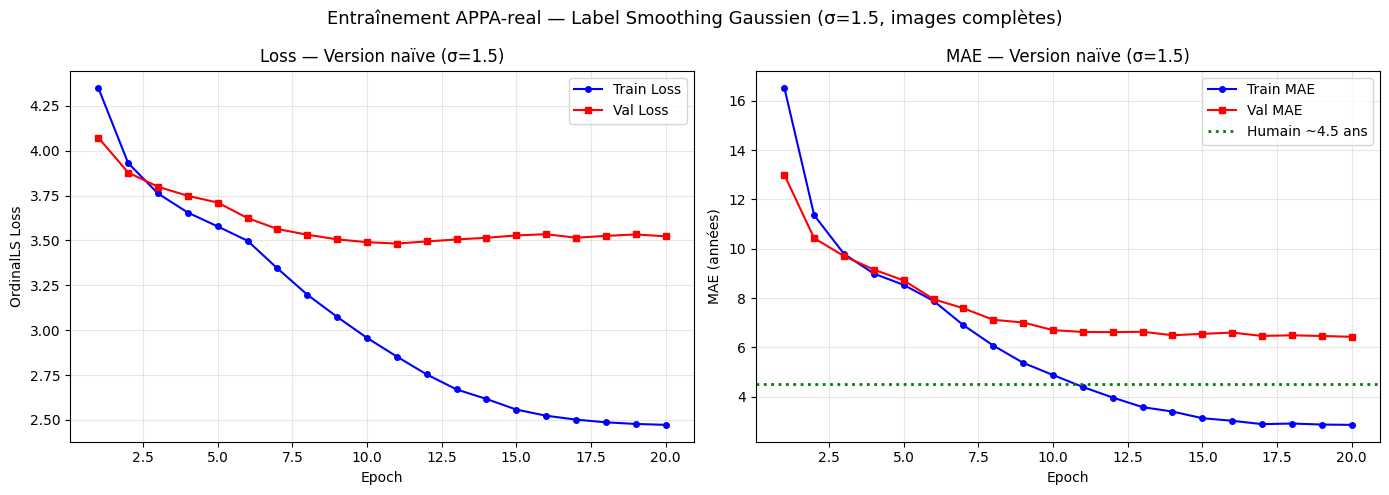

Meilleur Val MAE : 6.43 ans (epoch 20)


In [12]:
# ── Courbes entraînement v1 ───────────────────────────────────────────────────
epochs = range(1, len(history_v1["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history_v1["train_loss"], "b-o", label="Train Loss", markersize=4)
axes[0].plot(epochs, history_v1["val_loss"],   "r-s", label="Val Loss",   markersize=4)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("OrdinalLS Loss")
axes[0].set_title("Loss — Version naïve (σ=1.5)")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history_v1["train_mae"], "b-o", label="Train MAE", markersize=4)
axes[1].plot(epochs, history_v1["val_mae"],   "r-s", label="Val MAE",   markersize=4)
axes[1].axhline(y=4.5, color='green', linestyle=':', linewidth=2, label='Humain ~4.5 ans')
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE (années)")
axes[1].set_title("MAE — Version naïve (σ=1.5)")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Entraînement APPA-real — Label Smoothing Gaussien (σ=1.5, images complètes)", fontsize=13)
plt.tight_layout(); plt.show()
print(f"Meilleur Val MAE : {min(history_v1['val_mae']):.2f} ans (epoch {int(np.argmin(history_v1['val_mae']))+1})")

## Partie 2 — Label Smoothing amélioré : σ = 3.0, crop facial, batch 64

La version naïve atteint 6.43 ans de MAE sur la validation. Trois modifications apportées simultanément permettent de descendre à 5.73 ans.

Crop facial. Chaque image APPA-real est fournie en deux versions : l'image complète et un crop du visage détecté automatiquement (`_face.jpg`). Sur l'image complète, le réseau voit des informations non pertinentes — fond, vêtements, posture. En restreignant l'entrée au visage, on élimine ce bruit et on concentre la capacité du réseau sur les indices d'âge réels : rides, texture de peau, forme du visage.

σ : 1.5 → 3.0. À σ = 1.5, la gaussienne est trop piquée : le réseau converge vers un comportement quasi *one-hot*, les prédictions sont discrètes, et le MAE plafonne. À σ = 3.0, la distribution s'étale sur ±6 ans, les prédictions deviennent continues, et le réseau apprend à exploiter toute la forme de la distribution.

Cible float, batch 64, eta_min. On passe la valeur continue `apparent_age_avg` (ex. 34.7) directement à la loss, sans l'arrondir à 35. Le batch passe de 32 à 64 pour une meilleure estimation du gradient sur GPU T4. Et `eta_min=1e-6` dans le scheduler empêche le learning rate de tomber à 0 en fin d'entraînement.

In [13]:
# ── Transforms version améliorée (augmentations renforcées) ──────────────────
train_transform_v2 = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
    A.Affine(translate_percent=0.05, scale=(0.9, 1.1), rotate=(-20, 20), p=0.4),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

BATCH_SIZE_V2 = 64   # Fix #3 — 32 → 64
print("Chargement APPA-REAL — version améliorée (crop facial, batch=64) :")

train_ds_v2 = AgeDataset(CSV_ROOT / "gt_avg_train.csv", DATA_ROOT / "train",
                          train_transform_v2, use_face_crop=True)   # Fix #1
valid_ds_v2 = AgeDataset(CSV_ROOT / "gt_avg_valid.csv", DATA_ROOT / "valid",
                          valid_transform, use_face_crop=True)
test_ds_v2  = AgeDataset(CSV_ROOT / "gt_avg_test.csv",  DATA_ROOT / "test",
                          valid_transform, use_face_crop=True)

train_loader_v2 = DataLoader(train_ds_v2, batch_size=BATCH_SIZE_V2, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
valid_loader_v2 = DataLoader(valid_ds_v2, batch_size=BATCH_SIZE_V2, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader_v2  = DataLoader(test_ds_v2,  batch_size=BATCH_SIZE_V2, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
print(f"Train : {len(train_ds_v2)} | Valid : {len(valid_ds_v2)} | Test : {len(test_ds_v2)}")

Chargement APPA-REAL — version améliorée (crop facial, batch=64) :
   train : 4113 images (face crop activé, 4113 crops dispo)
   valid : 1500 images (face crop activé, 1500 crops dispo)
   test : 1978 images (face crop activé, 1978 crops dispo)
Train : 4113 | Valid : 1500 | Test : 1978


In [14]:
# ── Instanciation modèle amélioré (σ=3.0, crop facial, batch=64) ──────────────
_base_v2     = get_model("se_resnext50_32x4d", num_classes=NUM_CLASSES, pretrained="imagenet")
_base_v2.last_linear = nn.Identity()

model_v2     = AppaRealModel(_base_v2, embed_dim=embed_dim, num_classes=NUM_CLASSES).to(device)
criterion_v2 = OrdinalLabelSmoothing(num_classes=NUM_CLASSES, sigma=3.0)   # Fix #2

with torch.no_grad():
    _out = model_v2(torch.randn(2, 3, 224, 224).to(device))
    assert _out.shape == (2, NUM_CLASSES)
    print(f"✓ Forward v2 : logits {_out.shape}")

for p in model_v2.backbone.parameters():
    p.requires_grad = False

optimizer_v2 = torch.optim.AdamW([
    {"params": model_v2.bn.parameters(),   "lr": 1e-4},
    {"params": model_v2.head.parameters(), "lr": 1e-4},
], weight_decay=1e-4)
# Fix #3 — eta_min évite que lr tombe à 0
scheduler_v2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_v2, T_max=5, eta_min=1e-5)

trainable = sum(p.numel() for p in model_v2.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_v2.parameters())
print(f"Paramètres entraîn. : {trainable:,} / {total:,} (backbone gelé)")
print(f"σ = 3.0 | batch = 64 | crop facial activé")

✓ Forward v2 : logits torch.Size([2, 101])
Paramètres entraîn. : 555,109 / 26,066,005 (backbone gelé)
σ = 3.0 | batch = 64 | crop facial activé


In [15]:
# ── Entraînement — version améliorée (30 epochs) ─────────────────────────────
CKPT_V2 = "label_smoothing_v2_best.pth"

history_v2 = {"train_loss": [], "train_mae": [], "val_loss": [], "val_mae": []}
best_val_mae_v2 = math.inf

print(f"{'Ep':>3} | {'Train Loss':>10} | {'Train MAE':>9} | {'Val Loss':>8} | {'Val MAE':>7} | {'Mode':>12}")
print("-" * 72)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    if epoch == WARMUP_EPOCHS + 1:
        for p in model_v2.backbone.parameters():
            p.requires_grad = True
        optimizer_v2 = torch.optim.AdamW([
            {"params": model_v2.backbone.parameters(), "lr": 1e-5},
            {"params": model_v2.bn.parameters(),       "lr": 1e-4},
            {"params": model_v2.head.parameters(),     "lr": 1e-4},
        ], weight_decay=1e-4)
        scheduler_v2 = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer_v2, T_max=NUM_EPOCHS - WARMUP_EPOCHS, eta_min=1e-6)
        trainable = sum(p.numel() for p in model_v2.parameters() if p.requires_grad)
        print(f"      → Backbone dégelé ({trainable:,} params entraînables)")

    train_loss, train_mae = train_epoch(model_v2, train_loader_v2, optimizer_v2, criterion_v2, device)
    val_loss,   val_mae   = evaluate_epoch(model_v2, valid_loader_v2, criterion_v2, device)
    scheduler_v2.step()

    history_v2["train_loss"].append(train_loss)
    history_v2["train_mae"].append(train_mae)
    history_v2["val_loss"].append(val_loss)
    history_v2["val_mae"].append(val_mae)

    mode = "HEAD ONLY" if epoch <= WARMUP_EPOCHS else "FULL FT"
    print(f"{epoch:>3} | {train_loss:>10.4f} | {train_mae:>9.2f} | "
          f"{val_loss:>8.4f} | {val_mae:>7.2f}  ({time.time()-t0:.1f}s) | {mode:>12}")

    if val_mae < best_val_mae_v2:
        best_val_mae_v2 = val_mae
        torch.save({"epoch": epoch, "state_dict": model_v2.state_dict(),
                    "val_mae": val_mae}, CKPT_V2)
        print(f"      ✓ Checkpoint sauvegardé (MAE={val_mae:.2f})")

print(f"\nEntraînement terminé. Meilleur Val MAE : {best_val_mae_v2:.2f} ans")

 Ep | Train Loss | Train MAE | Val Loss | Val MAE |         Mode
------------------------------------------------------------------------
  1 |     4.4638 |     18.39 |   4.2199 |   15.25  (13.3s) |    HEAD ONLY
      ✓ Checkpoint sauvegardé (MAE=15.25)
  2 |     4.1430 |     13.59 |   4.0122 |   12.02  (7.9s) |    HEAD ONLY
      ✓ Checkpoint sauvegardé (MAE=12.02)
  3 |     3.9998 |     11.55 |   3.9376 |   10.93  (7.9s) |    HEAD ONLY
      ✓ Checkpoint sauvegardé (MAE=10.93)
  4 |     3.9368 |     10.78 |   3.8974 |   10.40  (8.1s) |    HEAD ONLY
      ✓ Checkpoint sauvegardé (MAE=10.40)
  5 |     3.9084 |     10.40 |   3.8867 |   10.31  (8.0s) |    HEAD ONLY
      ✓ Checkpoint sauvegardé (MAE=10.31)
      → Backbone dégelé (26,066,005 params entraînables)
  6 |     3.8453 |      9.67 |   3.7577 |    8.80  (17.6s) |      FULL FT
      ✓ Checkpoint sauvegardé (MAE=8.80)
  7 |     3.7205 |      8.43 |   3.6660 |    7.93  (7.9s) |      FULL FT
      ✓ Checkpoint sauvegardé (MAE=7.93)


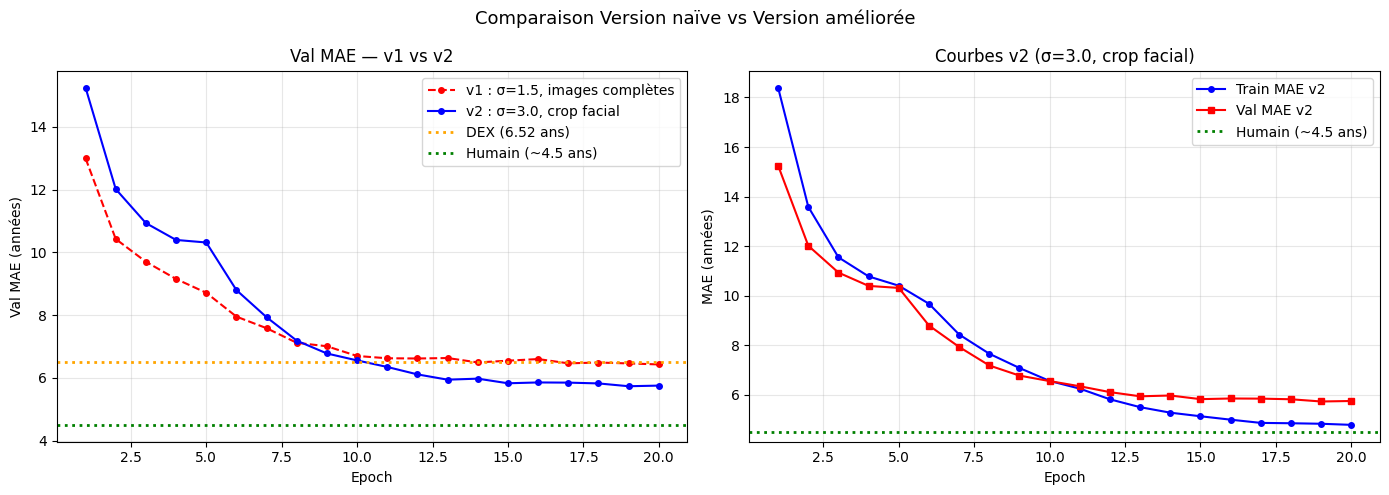

Meilleur Val MAE v1 : 6.43 ans
Meilleur Val MAE v2 : 5.73 ans
Gain v2 / v1        : 0.70 ans


In [16]:
# ── Courbes + comparaison v1 vs v2 ────────────────────────────────────────────
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history_v1["val_mae"],  "r--o", label="v1 : σ=1.5, images complètes", markersize=4)
axes[0].plot(epochs, history_v2["val_mae"],  "b-o",  label="v2 : σ=3.0, crop facial",       markersize=4)
axes[0].axhline(y=6.52, color='orange', linestyle=':', linewidth=2, label='DEX (6.52 ans)')
axes[0].axhline(y=4.50, color='green',  linestyle=':', linewidth=2, label='Humain (~4.5 ans)')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Val MAE (années)")
axes[0].set_title("Val MAE — v1 vs v2")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history_v2["train_mae"], "b-o", label="Train MAE v2", markersize=4)
axes[1].plot(epochs, history_v2["val_mae"],   "r-s", label="Val MAE v2",   markersize=4)
axes[1].axhline(y=4.50, color='green', linestyle=':', linewidth=2, label='Humain (~4.5 ans)')
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE (années)")
axes[1].set_title("Courbes v2 (σ=3.0, crop facial)")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Comparaison Version naïve vs Version améliorée", fontsize=13)
plt.tight_layout(); plt.show()

print(f"Meilleur Val MAE v1 : {min(history_v1['val_mae']):.2f} ans")
print(f"Meilleur Val MAE v2 : {min(history_v2['val_mae']):.2f} ans")
print(f"Gain v2 / v1        : {min(history_v1['val_mae']) - min(history_v2['val_mae']):.2f} ans")

### Test-Time Augmentation (TTA)

Le TTA est un post-traitement pur, sans réentraînement : on infère le modèle sur T = 5 vues augmentées de chaque image et on moyenne les prédictions.

$$\hat{a}_{\text{TTA}} = \frac{1}{T} \sum_{t=1}^{T} \hat{a}(\text{aug}_t(\mathbf{x}))$$

Les 5 vues sont : l'image originale, un flip horizontal, un léger ajustement de luminosité/contraste, une rotation de −10° et une rotation de +10°. Cette diversité couvre les principales variations d'apparence non capturées par le crop facial (orientation légère, conditions d'éclairage). Sur ce modèle, le gain est de 0.14 ans de MAE sur le jeu de test (6.94 → 6.79 ans).

In [17]:
# ── Évaluation finale v2 + TTA ─────────────────────────────────────────────────
_norm = [
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
]
tta_transforms = [
    A.Compose([A.Resize(224, 224)] + _norm),
    A.Compose([A.Resize(224, 224), A.HorizontalFlip(p=1.0)] + _norm),
    A.Compose([A.Resize(224, 224), A.RandomBrightnessContrast(0.15, 0.15, p=1.0)] + _norm),
    A.Compose([A.Resize(224, 224), A.Affine(rotate=(-10, -10), p=1.0)] + _norm),
    A.Compose([A.Resize(224, 224), A.Affine(rotate=(10, 10), p=1.0)] + _norm),
]


def predict_with_tta(model, img_bgr, transforms, device):
    model.eval()
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    preds = []
    with torch.no_grad():
        for tfm in transforms:
            tensor = tfm(image=img_rgb)["image"].unsqueeze(0).to(device)
            logits = model(tensor)
            preds.append(model.head.predict_age(logits).item())
    return float(np.mean(preds))


# Charger le meilleur checkpoint v2
ckpt_v2 = torch.load(CKPT_V2, map_location=device)
model_v2.load_state_dict(ckpt_v2["state_dict"])
model_v2.eval()

# Évaluation sans TTA
all_preds_v2, all_gt_v2 = [], []
with torch.no_grad():
    for imgs, _, age_float, _, _ in test_loader_v2:
        preds = model_v2.predict(imgs.to(device)).cpu().numpy()
        all_preds_v2.extend(preds)
        all_gt_v2.extend(age_float.numpy())
all_preds_v2 = np.array(all_preds_v2)
all_gt_v2    = np.array(all_gt_v2)
errors_v2    = np.abs(all_preds_v2 - all_gt_v2)

# Évaluation avec TTA
print("Évaluation TTA sur le test set ...")
t0 = time.time()
all_preds_tta, all_gt_tta = [], []
for idx in range(len(test_ds_v2)):
    row    = test_ds_v2.df.iloc[idx]
    age_gt = float(row[test_ds_v2.age_col])
    face_p = test_ds_v2.img_dir / (row["file_name"] + "_face.jpg")
    full_p = test_ds_v2.img_dir / row["file_name"]
    img    = cv2.imread(str(face_p if face_p.exists() else full_p))
    if img is None:
        img = np.zeros((224, 224, 3), dtype=np.uint8)
    all_preds_tta.append(predict_with_tta(model_v2, img, tta_transforms, device))
    all_gt_tta.append(age_gt)
all_preds_tta = np.array(all_preds_tta)
all_gt_tta    = np.array(all_gt_tta)
errors_tta    = np.abs(all_preds_tta - all_gt_tta)

print(f"Temps TTA : {time.time()-t0:.1f}s")
print("\n══════════════════════════════════════════════════")
print("  Comparaison MAE — sans TTA vs avec TTA")
print("══════════════════════════════════════════════════")
print(f"  Sans TTA : MAE = {errors_v2.mean():.3f} ans  |  RMSE = {np.sqrt((errors_v2**2).mean()):.3f} ans")
print(f"  Avec TTA : MAE = {errors_tta.mean():.3f} ans  |  RMSE = {np.sqrt((errors_tta**2).mean()):.3f} ans")
print(f"  Gain TTA : Δ MAE = {errors_v2.mean() - errors_tta.mean():+.3f} ans")
print("══════════════════════════════════════════════════")

Évaluation TTA sur le test set ...
Temps TTA : 66.1s

══════════════════════════════════════════════════
  Comparaison MAE — sans TTA vs avec TTA
══════════════════════════════════════════════════
  Sans TTA : MAE = 6.937 ans  |  RMSE = 10.049 ans
  Avec TTA : MAE = 6.792 ans  |  RMSE = 9.777 ans
  Gain TTA : Δ MAE = +0.145 ans
══════════════════════════════════════════════════


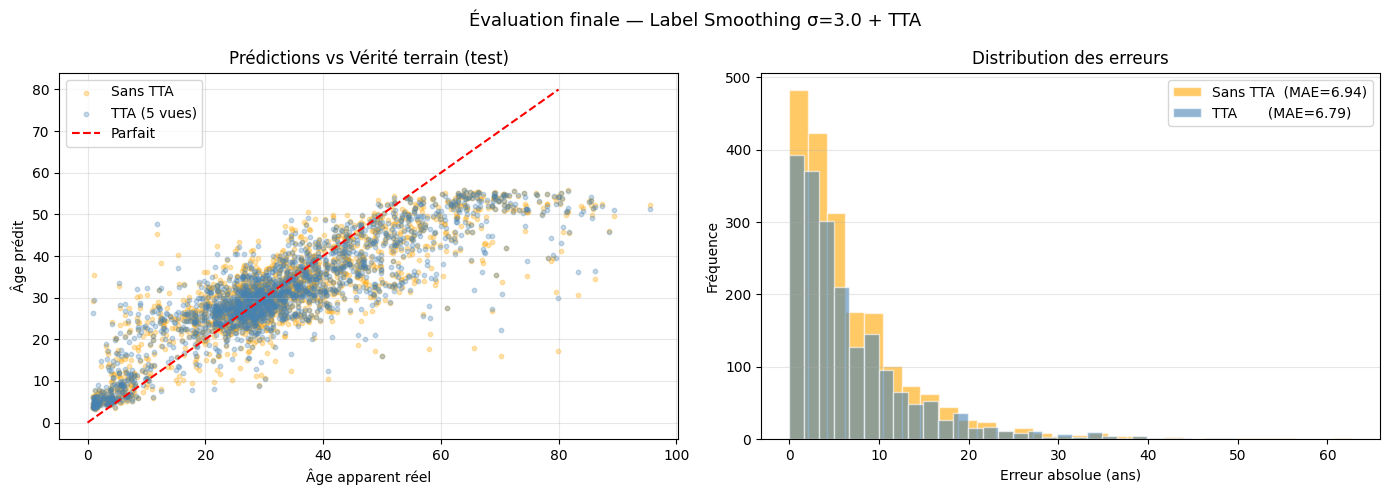

In [18]:
# ── Scatter + distribution des erreurs v2 ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(all_gt_v2,  all_preds_v2,  alpha=0.3, s=10, color='orange',    label='Sans TTA')
axes[0].scatter(all_gt_tta, all_preds_tta, alpha=0.3, s=10, color='steelblue', label='TTA (5 vues)')
axes[0].plot([0, 80], [0, 80], 'r--', linewidth=1.5, label='Parfait')
axes[0].set_xlabel('Âge apparent réel'); axes[0].set_ylabel('Âge prédit')
axes[0].set_title('Prédictions vs Vérité terrain (test)')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(errors_v2,  bins=30, alpha=0.6, color='orange',    edgecolor='white',
             label=f'Sans TTA  (MAE={errors_v2.mean():.2f})')
axes[1].hist(errors_tta, bins=30, alpha=0.6, color='steelblue', edgecolor='white',
             label=f'TTA       (MAE={errors_tta.mean():.2f})')
axes[1].set_xlabel('Erreur absolue (ans)'); axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution des erreurs')
axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('Évaluation finale — Label Smoothing σ=3.0 + TTA', fontsize=13)
plt.tight_layout(); plt.show()

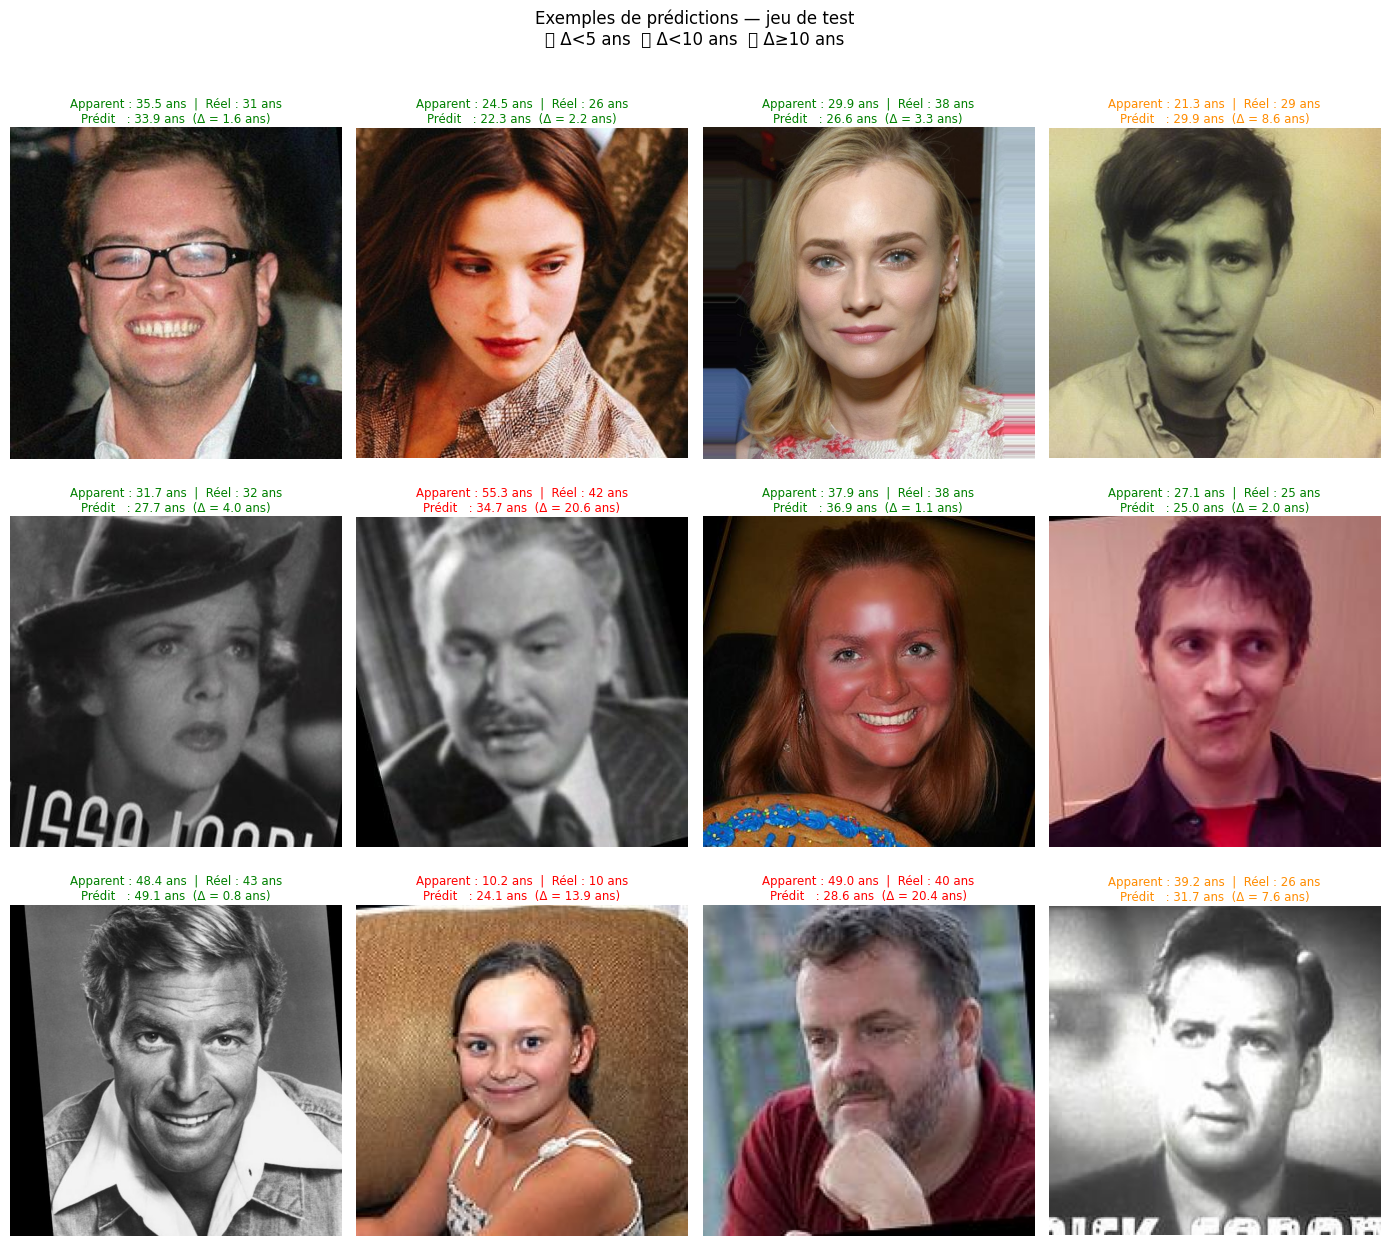

In [19]:
# ── Visualisation des prédictions sur des exemples test ───────────────────────
N_SHOW = min(12, len(test_ds_v2))
COLS   = min(4, N_SHOW)
ROWS   = math.ceil(N_SHOW / COLS)
indices = random.sample(range(len(test_ds_v2)), N_SHOW)

fig, axes = plt.subplots(ROWS, COLS, figsize=(COLS * 3.5, ROWS * 4.2))
axes_flat = np.array(axes).flatten()

model_v2.eval()
with torch.no_grad():
    for plot_i, idx in enumerate(indices):
        row       = test_ds_v2.df.iloc[idx]
        age_float = float(row[test_ds_v2.age_col])
        real_age  = float(row["real_age"]) if "real_age" in test_ds_v2.df.columns else age_float

        face_p   = test_ds_v2.img_dir / (row["file_name"] + "_face.jpg")
        full_p   = test_ds_v2.img_dir / row["file_name"]
        img_raw  = cv2.imread(str(face_p if face_p.exists() else full_p))
        if img_raw is not None:
            img_raw = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
        else:
            img_raw = np.zeros((224, 224, 3), dtype=np.uint8)

        img_tensor, *_ = test_ds_v2[idx]
        pred = model_v2.predict(img_tensor.unsqueeze(0).to(device)).item()
        err  = abs(pred - age_float)
        color = "green" if err < 5 else ("darkorange" if err < 10 else "red")

        axes_flat[plot_i].imshow(img_raw)
        axes_flat[plot_i].set_title(
            f"Apparent : {age_float:.1f} ans  |  Réel : {real_age:.0f} ans\n"
            f"Prédit   : {pred:.1f} ans  (Δ = {err:.1f} ans)",
            fontsize=8.5, color=color, pad=4)
        axes_flat[plot_i].axis("off")

for ax in axes_flat[N_SHOW:]:
    ax.axis("off")

plt.suptitle("Exemples de prédictions — jeu de test\n🟢 Δ<5 ans  🟠 Δ<10 ans  🔴 Δ≥10 ans",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Partie 3 — Mean-Variance Loss et CORAL

Les deux méthodes qui suivent partagent le même backbone et les mêmes dataloaders que la version améliorée (crop facial, batch 64). Seule la loss change — et pour CORAL, la tête de classification également.

### 3.1 Mean-Variance Loss — Pan et al., CVPR 2018

Le Label Smoothing impose un σ fixe à toutes les images. La Mean-Variance Loss supprime ce choix arbitraire : au lieu d'imposer une distribution cible, elle régularise directement la distribution prédite par le réseau.

$$\mathcal{L}_{\text{MV}} = \mathcal{L}_{\text{CE}} + \lambda_1 \underbrace{(\hat{\mu} - \mu^*)^2}_{\text{erreur de moyenne}} + \lambda_2 \underbrace{\hat{\sigma}^2}_{\text{régularisation de variance}}$$

où $\hat{\mu} = \sum_k k \cdot p_k$ est l'espérance prédite et $\hat{\sigma}^2 = \sum_k (k - \hat{\mu})^2 \cdot p_k$ sa variance. La cross-entropie $\mathcal{L}_{\text{CE}}$ porte sur l'âge arrondi à l'entier, $\lambda_1 = 0.2$ pénalise l'écart de moyenne, et $\lambda_2 = 0.05$ décourage un étalement excessif de la distribution.

### 3.2 CORAL — Cao et al., Pattern Recognition Letters 2020

La cross-entropie classique traite les 101 bins comme des classes indépendantes. Rien n'interdit formellement que $P(y > 50) < P(y > 60)$, ce qui est ordinalement incohérent. CORAL propose une alternative qui garantit cette cohérence par construction.

Au lieu d'une sortie à 101 classes, CORAL décompose le problème en 100 classifieurs binaires ordonnés : $P(\hat{y} > k)$ pour $k \in \{0, \ldots, 99\}$. Dans la formulation originale, tous partagent les mêmes poids $\mathbf{W}$ mais ont des biais distincts $b_k$. Ici, on utilise une couche linéaire complète (256→100) pour donner à chaque seuil son propre vecteur de poids, ce qui améliore la capacité discriminante sans renoncer à la structure ordinale de la loss et de la prédiction.

$$f_k(\mathbf{x}) = \mathbf{W}_k^\top \mathbf{x} + b_k$$

L'initialisation est critique : les biais sont fixés à $b_k = \log\!\left(\frac{K-k}{k+1}\right)$ pour que les probabilités $P(y > k)$ soient strictement décroissantes dès le départ, ce qui évite que le modèle prédise uniquement 0 ou 100 ans au début de l'entraînement.

La loss est une somme de $K-1$ binary cross-entropies :

$$\mathcal{L}_{\text{CORAL}} = \frac{1}{K-1} \sum_{k=0}^{K-2} \text{BCE}\!\left(\sigma(f_k(\mathbf{x})),\ \mathbf{1}[y > k]\right)$$

La prédiction est le nombre de seuils franchis : $\hat{a} = \sum_{k=0}^{K-2} \mathbf{1}[\sigma(f_k) > 0.5]$.

In [20]:
class MeanVarianceLoss(nn.Module):
    """
    Pan et al., CVPR 2018 — Mean-Variance Loss pour la classification d'âge.

    L = CE(logits, age_int) + λ1·(µ_pred - µ*)² + λ2·σ²_pred

    ⚠️ register_buffer : appeler .to(device) après instanciation.
    """
    def __init__(self, num_classes: int = 101,
                 lambda_mean: float = 0.2, lambda_var: float = 0.05):
        super().__init__()
        self.lambda_mean = lambda_mean
        self.lambda_var  = lambda_var
        self.register_buffer('classes', torch.arange(num_classes).float())

    def forward(self, logits: torch.Tensor, targets_float: torch.Tensor) -> torch.Tensor:
        probs   = F.softmax(logits, dim=-1)                           # (B, K)
        mu_pred = (probs * self.classes).sum(dim=-1)                  # (B,)
        var_pred = (probs * (self.classes - mu_pred.unsqueeze(1))**2).sum(dim=-1)  # (B,)

        # CE standard sur l'âge entier arrondi
        targets_int = targets_float.long().clamp(0, len(self.classes) - 1)
        loss_ce  = F.cross_entropy(logits, targets_int)
        loss_mean = ((mu_pred - targets_float) ** 2).mean()
        loss_var  = var_pred.mean()

        return loss_ce + self.lambda_mean * loss_mean + self.lambda_var * loss_var

In [22]:
# ── Architecture MV : même backbone, même tête ───────────────────────────────
class MVAgeHead(nn.Module):
    """Tête linéaire 2048→256→101 avec softmax expectation."""
    def __init__(self, embed_dim: int = 2048, num_classes: int = 101, dropout: float = 0.3):
        super().__init__()
        self.bins = torch.arange(num_classes).float()
        self.head = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x): return self.head(x)

    def predict_age(self, logits):
        bins  = self.bins.to(logits.device)
        probs = F.softmax(logits, dim=-1)
        return (probs * bins).sum(dim=-1)


class MVAgeModel(nn.Module):
    def __init__(self, backbone, embed_dim=2048, num_classes=101):
        super().__init__()
        self.backbone = backbone
        self.flatten  = nn.Flatten(1)
        self.bn       = nn.BatchNorm1d(embed_dim)
        self.head     = MVAgeHead(embed_dim, num_classes)

    def forward(self, x):
        return self.head(self.bn(self.flatten(self.backbone(x))))

    def predict(self, x):
        return self.head.predict_age(self.forward(x))


# Instanciation
_base_mv = get_model("se_resnext50_32x4d", num_classes=NUM_CLASSES, pretrained="imagenet")
_base_mv.last_linear = nn.Identity()

model_mv     = MVAgeModel(_base_mv, embed_dim=embed_dim, num_classes=NUM_CLASSES).to(device)
# MeanVarianceLoss n'a que des buffers (register_buffer), pas de paramètres entraînables.
# Il faut appeler .to(device) pour déplacer le buffer 'classes' sur GPU.
criterion_mv = MeanVarianceLoss(num_classes=NUM_CLASSES, lambda_mean=0.2, lambda_var=0.05).to(device)

with torch.no_grad():
    _out = model_mv(torch.randn(2, 3, 224, 224).to(device))
    assert _out.shape == (2, NUM_CLASSES)
    ages = model_mv.head.predict_age(_out)
    print(f"✓ Forward MV : logits {_out.shape} → âges {ages.shape}")

total = sum(p.numel() for p in model_mv.parameters())
print(f"Paramètres total : {total:,}")
# MeanVarianceLoss a des buffers (pas des paramètres) → next(buffers()) pour le device
buf_device = next(criterion_mv.buffers()).device
print(f"λ_mean = 0.2 | λ_var = 0.05 | buffer 'classes' sur device : {buf_device}")

✓ Forward MV : logits torch.Size([2, 101]) → âges torch.Size([2])
Paramètres total : 26,066,005
λ_mean = 0.2 | λ_var = 0.05 | buffer 'classes' sur device : cuda:0


In [23]:
# ── Entraînement MV (mêmes dataloaders v2 : crop facial, batch=64) ─────────────
CKPT_MV = "mv_loss_best.pth"

# Phase warmup
for p in model_mv.backbone.parameters():
    p.requires_grad = False

optimizer_mv = torch.optim.AdamW([
    {"params": model_mv.bn.parameters(),   "lr": 1e-4},
    {"params": model_mv.head.parameters(), "lr": 1e-4},
], weight_decay=1e-4)
scheduler_mv = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_mv, T_max=5, eta_min=1e-5)

history_mv  = {"train_loss": [], "train_mae": [], "val_loss": [], "val_mae": []}
best_mv_mae = math.inf


def train_epoch_mv(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_mae, n = 0.0, 0.0, 0
    for imgs, _, age_float, _, _ in loader:
        imgs      = imgs.to(device, non_blocking=True)
        age_float = age_float.to(device, dtype=torch.float32)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, age_float)
        loss.backward()
        optimizer.step()
        with torch.no_grad():
            mae = (model.head.predict_age(logits) - age_float).abs().sum()
        bs = imgs.size(0)
        total_loss += loss.item() * bs
        total_mae  += mae.item()
        n          += bs
    return total_loss / n, total_mae / n


def eval_epoch_mv(model, loader, criterion, device):
    model.eval()
    total_loss, total_mae, n = 0.0, 0.0, 0
    with torch.no_grad():
        for imgs, _, age_float, _, _ in loader:
            imgs      = imgs.to(device, non_blocking=True)
            age_float = age_float.to(device, dtype=torch.float32)
            logits    = model(imgs)
            loss      = criterion(logits, age_float)
            mae       = (model.head.predict_age(logits) - age_float).abs().sum()
            bs = imgs.size(0)
            total_loss += loss.item() * bs
            total_mae  += mae.item()
            n          += bs
    return total_loss / n, total_mae / n


print(f"{'Ep':>3} | {'Train Loss':>10} | {'Train MAE':>9} | {'Val Loss':>8} | {'Val MAE':>7} | {'Mode':>12}")
print("-" * 72)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    if epoch == WARMUP_EPOCHS + 1:
        for p in model_mv.backbone.parameters():
            p.requires_grad = True
        optimizer_mv = torch.optim.AdamW([
            {"params": model_mv.backbone.parameters(), "lr": 1e-5},
            {"params": model_mv.bn.parameters(),       "lr": 1e-4},
            {"params": model_mv.head.parameters(),     "lr": 1e-4},
        ], weight_decay=1e-4)
        scheduler_mv = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer_mv, T_max=NUM_EPOCHS - WARMUP_EPOCHS, eta_min=1e-6)
        trainable = sum(p.numel() for p in model_mv.parameters() if p.requires_grad)
        print(f"      → Backbone dégelé ({trainable:,} params entraînables)")

    train_loss, train_mae = train_epoch_mv(model_mv, train_loader_v2, optimizer_mv, criterion_mv, device)
    val_loss,   val_mae   = eval_epoch_mv(model_mv, valid_loader_v2, criterion_mv, device)
    scheduler_mv.step()

    history_mv["train_loss"].append(train_loss)
    history_mv["train_mae"].append(train_mae)
    history_mv["val_loss"].append(val_loss)
    history_mv["val_mae"].append(val_mae)

    mode = "HEAD ONLY" if epoch <= WARMUP_EPOCHS else "FULL FT"
    print(f"{epoch:>3} | {train_loss:>10.4f} | {train_mae:>9.2f} | "
          f"{val_loss:>8.4f} | {val_mae:>7.2f}  ({time.time()-t0:.1f}s) | {mode:>12}")

    if val_mae < best_mv_mae:
        best_mv_mae = val_mae
        torch.save({"epoch": epoch, "state_dict": model_mv.state_dict(),
                    "val_mae": val_mae}, CKPT_MV)
        print(f"      ✓ Checkpoint MV sauvegardé (MAE={val_mae:.2f})")

print(f"\nMeilleur Val MAE MV : {best_mv_mae:.2f} ans")

 Ep | Train Loss | Train MAE | Val Loss | Val MAE |         Mode
------------------------------------------------------------------------
  1 |   116.0937 |     16.24 |  81.1393 |   12.18  (7.6s) |    HEAD ONLY
  1 |   116.0937 |     16.24 |  81.1393 |   12.18  (7.6s) |    HEAD ONLY
      ✓ Checkpoint MV sauvegardé (MAE=12.18)
      ✓ Checkpoint MV sauvegardé (MAE=12.18)
  2 |    69.8684 |     10.68 |  62.8525 |    9.80  (7.6s) |    HEAD ONLY
      ✓ Checkpoint MV sauvegardé (MAE=9.80)
  2 |    69.8684 |     10.68 |  62.8525 |    9.80  (7.6s) |    HEAD ONLY
      ✓ Checkpoint MV sauvegardé (MAE=9.80)
  3 |    59.3736 |      9.49 |  56.1084 |    9.06  (7.6s) |    HEAD ONLY
      ✓ Checkpoint MV sauvegardé (MAE=9.06)
  3 |    59.3736 |      9.49 |  56.1084 |    9.06  (7.6s) |    HEAD ONLY
      ✓ Checkpoint MV sauvegardé (MAE=9.06)
  4 |    54.3699 |      9.02 |  53.3157 |    8.82  (7.7s) |    HEAD ONLY
  4 |    54.3699 |      9.02 |  53.3157 |    8.82  (7.7s) |    HEAD ONLY
      ✓ Chec

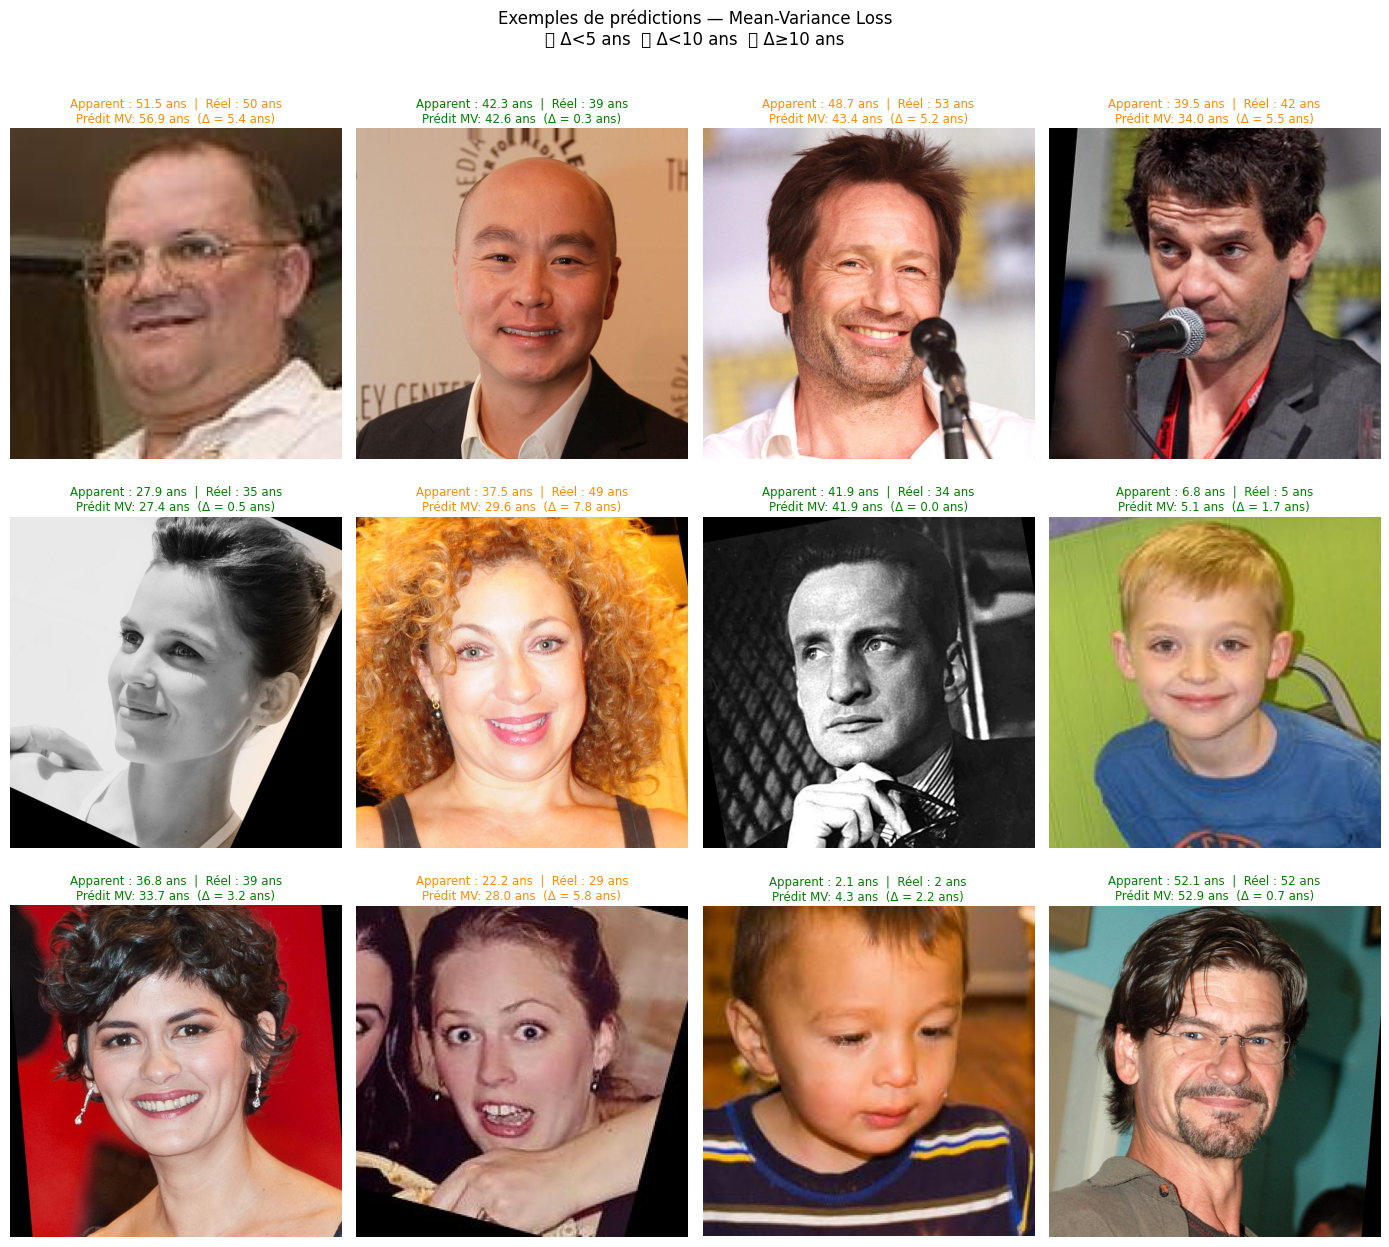

In [30]:
# ── Visualisation des prédictions MV sur des exemples test ───────────────────
ckpt_mv = torch.load(CKPT_MV, map_location=device)
model_mv.load_state_dict(ckpt_mv["state_dict"])

N_SHOW = min(12, len(test_ds_v2))
COLS   = min(4, N_SHOW)
ROWS   = math.ceil(N_SHOW / COLS)
indices = random.sample(range(len(test_ds_v2)), N_SHOW)

fig, axes = plt.subplots(ROWS, COLS, figsize=(COLS * 3.5, ROWS * 4.2))
axes_flat = np.array(axes).flatten()

model_mv.eval()
with torch.no_grad():
    for plot_i, idx in enumerate(indices):
        row       = test_ds_v2.df.iloc[idx]
        age_float = float(row[test_ds_v2.age_col])
        real_age  = float(row["real_age"]) if "real_age" in test_ds_v2.df.columns else age_float

        face_p   = test_ds_v2.img_dir / (row["file_name"] + "_face.jpg")
        full_p   = test_ds_v2.img_dir / row["file_name"]
        img_raw  = cv2.imread(str(face_p if face_p.exists() else full_p))
        if img_raw is not None:
            img_raw = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
        else:
            img_raw = np.zeros((224, 224, 3), dtype=np.uint8)

        img_tensor, *_ = test_ds_v2[idx]
        pred = model_mv.predict(img_tensor.unsqueeze(0).to(device)).item()
        err  = abs(pred - age_float)
        color = "green" if err < 5 else ("darkorange" if err < 10 else "red")

        axes_flat[plot_i].imshow(img_raw)
        axes_flat[plot_i].set_title(
            f"Apparent : {age_float:.1f} ans  |  Réel : {real_age:.0f} ans\n"
            f"Prédit MV: {pred:.1f} ans  (Δ = {err:.1f} ans)",
            fontsize=8.5, color=color, pad=4)
        axes_flat[plot_i].axis("off")

for ax in axes_flat[N_SHOW:]:
    ax.axis("off")

plt.suptitle("Exemples de prédictions — Mean-Variance Loss\n🟢 Δ<5 ans  🟠 Δ<10 ans  🔴 Δ≥10 ans",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [26]:
class CoralHead(nn.Module):
    """
    Tête CORAL (Cao et al., PRL 2020) — version capacité complète.

    Le CORAL strict (poids partagés 256→1 + biais distincts) limite le réseau
    à résumer chaque image en un seul scalaire h, ce qui est insuffisant sur
    APPA-real (MAE ~8-9 ans). On remplace par fc: 256→(K-1) : chaque seuil
    dispose de son propre vecteur de poids. La cohérence ordinale reste
    encouragée par la loss (K-1 BCE ordonnées) et la prédiction par comptage.

    Initialisation :
      - fc.weight ~ N(0, 0.01)  → logits petits à t=0, sigmoid ≈ 0.5
      - fc.bias[k] = log((K-k)/(k+1))  → P(y>k) strictement décroissant
        → âges prédits ≈ K/2 ≈ 50 ans dès le départ
    """
    def __init__(self, embed_dim: int = 2048, num_classes: int = 101, dropout: float = 0.3):
        super().__init__()
        K = num_classes - 1   # nombre de seuils (100)

        self.proj = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        # K-1 sorties : chaque seuil a son propre vecteur de poids
        self.fc = nn.Linear(256, K, bias=True)
        nn.init.normal_(self.fc.weight, std=0.01)
        # Biais ordinaux : P(y>k) décroissant à l'initialisation
        init_bias = torch.tensor(
            [math.log((K - k) / (k + 1) + 1e-6) for k in range(K)],
            dtype=torch.float32
        ).clamp(-4.0, 4.0)
        self.fc.bias = nn.Parameter(init_bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.fc(self.proj(x))   # (B, K-1)

    def predict_age(self, logits: torch.Tensor) -> torch.Tensor:
        """Nombre de seuils franchis P(y>k) > 0.5 → âge entier."""
        return (torch.sigmoid(logits) > 0.5).sum(dim=-1).float()   # (B,)


class CoralLoss(nn.Module):
    """Somme des K-1 binary cross-entropies ordinales."""
    def forward(self, logits: torch.Tensor, targets_float: torch.Tensor) -> torch.Tensor:
        K       = logits.size(1) + 1
        targets = targets_float.long().clamp(0, K - 1)
        levels  = torch.arange(K - 1, device=logits.device).unsqueeze(0)   # (1, K-1)
        binary  = (targets.unsqueeze(1) > levels).float()                  # (B, K-1)
        return F.binary_cross_entropy_with_logits(logits, binary)


class CoralModel(nn.Module):
    def __init__(self, backbone, embed_dim=2048, num_classes=101, dropout=0.3):
        super().__init__()
        self.backbone = backbone
        self.flatten  = nn.Flatten(1)
        self.bn       = nn.BatchNorm1d(embed_dim)
        self.head     = CoralHead(embed_dim, num_classes, dropout)

    def forward(self, x):
        feat = self.flatten(self.backbone(x))
        return self.head(self.bn(feat))       # (B, K-1)

    def predict(self, x):
        return self.head.predict_age(self.forward(x))   # (B,) entier


# ── Instanciation ─────────────────────────────────────────────────────────────
_base_coral = get_model("se_resnext50_32x4d", num_classes=NUM_CLASSES, pretrained="imagenet")
_base_coral.last_linear = nn.Identity()

model_coral     = CoralModel(_base_coral, embed_dim=embed_dim, num_classes=NUM_CLASSES).to(device)
criterion_coral = CoralLoss()

# ── Sanity-check ──────────────────────────────────────────────────────────────
model_coral.eval()
with torch.no_grad():
    _out  = model_coral(torch.randn(4, 3, 224, 224).to(device))
    _ages = model_coral.head.predict_age(_out)
    _p    = torch.sigmoid(_out[0]).cpu().numpy()
    assert _out.shape == (4, NUM_CLASSES - 1), f"Shape inattendu : {_out.shape}"
    print(f"✓ Forward CORAL : logits {_out.shape}")
    print(f"  Âges prédits init : {_ages.cpu().numpy()}  (doivent être ~50)")
    print(f"  P(y>0)={_p[0]:.2f}  P(y>50)={_p[50]:.2f}  P(y>99)={_p[99]:.2f}")
    mono = all(_p[i] >= _p[i+1] for i in range(len(_p)-1))
    print(f"  → {'✓ décroissant' if mono else '✗ NON strictement décroissant (normal avec fc 256→K)'}")
model_coral.train()

✓ Forward CORAL : logits torch.Size([4, 100])
  Âges prédits init : [49. 49. 49. 49.]  (doivent être ~50)
  P(y>0)=0.98  P(y>50)=0.49  P(y>99)=0.02
  → ✗ NON strictement décroissant (normal avec fc 256→K)


CoralModel(
  (backbone): SENet(
    (layer0): Sequential(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU(inplace=True)
      (pool): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    )
    (layer1): Sequential(
      (0): SEResNeXtBottleneck(
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(128, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [27]:
# ── Entraînement CORAL ────────────────────────────────────────────────────────
CKPT_CORAL = "coral_best.pth"

for p in model_coral.backbone.parameters():
    p.requires_grad = False

optimizer_coral = torch.optim.AdamW([
    {"params": model_coral.bn.parameters(),   "lr": 1e-4},
    {"params": model_coral.head.parameters(), "lr": 1e-4},
], weight_decay=1e-4)
scheduler_coral = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_coral, T_max=5, eta_min=1e-5)

history_coral  = {"train_loss": [], "train_mae": [], "val_loss": [], "val_mae": []}
best_coral_mae = math.inf

print(f"{'Ep':>3} | {'Train Loss':>10} | {'Train MAE':>9} | {'Val Loss':>8} | {'Val MAE':>7} | {'Mode':>12}")
print("-" * 72)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    if epoch == WARMUP_EPOCHS + 1:
        for p in model_coral.backbone.parameters():
            p.requires_grad = True
        optimizer_coral = torch.optim.AdamW([
            {"params": model_coral.backbone.parameters(), "lr": 1e-5},
            {"params": model_coral.bn.parameters(),       "lr": 1e-4},
            {"params": model_coral.head.parameters(),     "lr": 1e-4},
        ], weight_decay=1e-4)
        scheduler_coral = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer_coral, T_max=NUM_EPOCHS - WARMUP_EPOCHS, eta_min=1e-6)
        trainable = sum(p.numel() for p in model_coral.parameters() if p.requires_grad)
        print(f"      → Backbone dégelé ({trainable:,} params entraînables)")

    # Train
    model_coral.train()
    tl, tm, n = 0.0, 0.0, 0
    for imgs, _, age_float, _, _ in train_loader_v2:
        imgs      = imgs.to(device, non_blocking=True)
        age_float = age_float.to(device, dtype=torch.float32)
        optimizer_coral.zero_grad()
        logits = model_coral(imgs)
        loss   = criterion_coral(logits, age_float)
        loss.backward()
        optimizer_coral.step()
        with torch.no_grad():
            mae = (model_coral.head.predict_age(logits) - age_float).abs().sum()
        bs = imgs.size(0)
        tl += loss.item() * bs; tm += mae.item(); n += bs
    train_loss, train_mae = tl / n, tm / n

    # Eval
    model_coral.eval()
    vl, vm, n = 0.0, 0.0, 0
    with torch.no_grad():
        for imgs, _, age_float, _, _ in valid_loader_v2:
            imgs      = imgs.to(device, non_blocking=True)
            age_float = age_float.to(device, dtype=torch.float32)
            logits    = model_coral(imgs)
            loss      = criterion_coral(logits, age_float)
            mae       = (model_coral.head.predict_age(logits) - age_float).abs().sum()
            bs = imgs.size(0)
            vl += loss.item() * bs; vm += mae.item(); n += bs
    val_loss, val_mae = vl / n, vm / n
    scheduler_coral.step()

    history_coral["train_loss"].append(train_loss)
    history_coral["train_mae"].append(train_mae)
    history_coral["val_loss"].append(val_loss)
    history_coral["val_mae"].append(val_mae)

    mode = "HEAD ONLY" if epoch <= WARMUP_EPOCHS else "FULL FT"
    print(f"{epoch:>3} | {train_loss:>10.4f} | {train_mae:>9.2f} | "
          f"{val_loss:>8.4f} | {val_mae:>7.2f}  ({time.time()-t0:.1f}s) | {mode:>12}")

    if val_mae < best_coral_mae:
        best_coral_mae = val_mae
        torch.save({"epoch": epoch, "state_dict": model_coral.state_dict(),
                    "val_mae": val_mae}, CKPT_CORAL)
        print(f"      ✓ Checkpoint CORAL sauvegardé (MAE={val_mae:.2f})")

print(f"\nMeilleur Val MAE CORAL : {best_coral_mae:.2f} ans")

 Ep | Train Loss | Train MAE | Val Loss | Val MAE |         Mode
------------------------------------------------------------------------
  1 |     0.3911 |     16.05 |   0.3376 |   11.66  (7.4s) |    HEAD ONLY
      ✓ Checkpoint CORAL sauvegardé (MAE=11.66)
  1 |     0.3911 |     16.05 |   0.3376 |   11.66  (7.4s) |    HEAD ONLY
      ✓ Checkpoint CORAL sauvegardé (MAE=11.66)
  2 |     0.3078 |     10.40 |   0.2782 |    9.36  (7.4s) |    HEAD ONLY
  2 |     0.3078 |     10.40 |   0.2782 |    9.36  (7.4s) |    HEAD ONLY
      ✓ Checkpoint CORAL sauvegardé (MAE=9.36)
      ✓ Checkpoint CORAL sauvegardé (MAE=9.36)
  3 |     0.2661 |      9.25 |   0.2510 |    9.07  (7.7s) |    HEAD ONLY
  3 |     0.2661 |      9.25 |   0.2510 |    9.07  (7.7s) |    HEAD ONLY
      ✓ Checkpoint CORAL sauvegardé (MAE=9.07)
      ✓ Checkpoint CORAL sauvegardé (MAE=9.07)
  4 |     0.2480 |      9.12 |   0.2378 |    8.89  (7.5s) |    HEAD ONLY
      ✓ Checkpoint CORAL sauvegardé (MAE=8.89)
  4 |     0.2480 |  

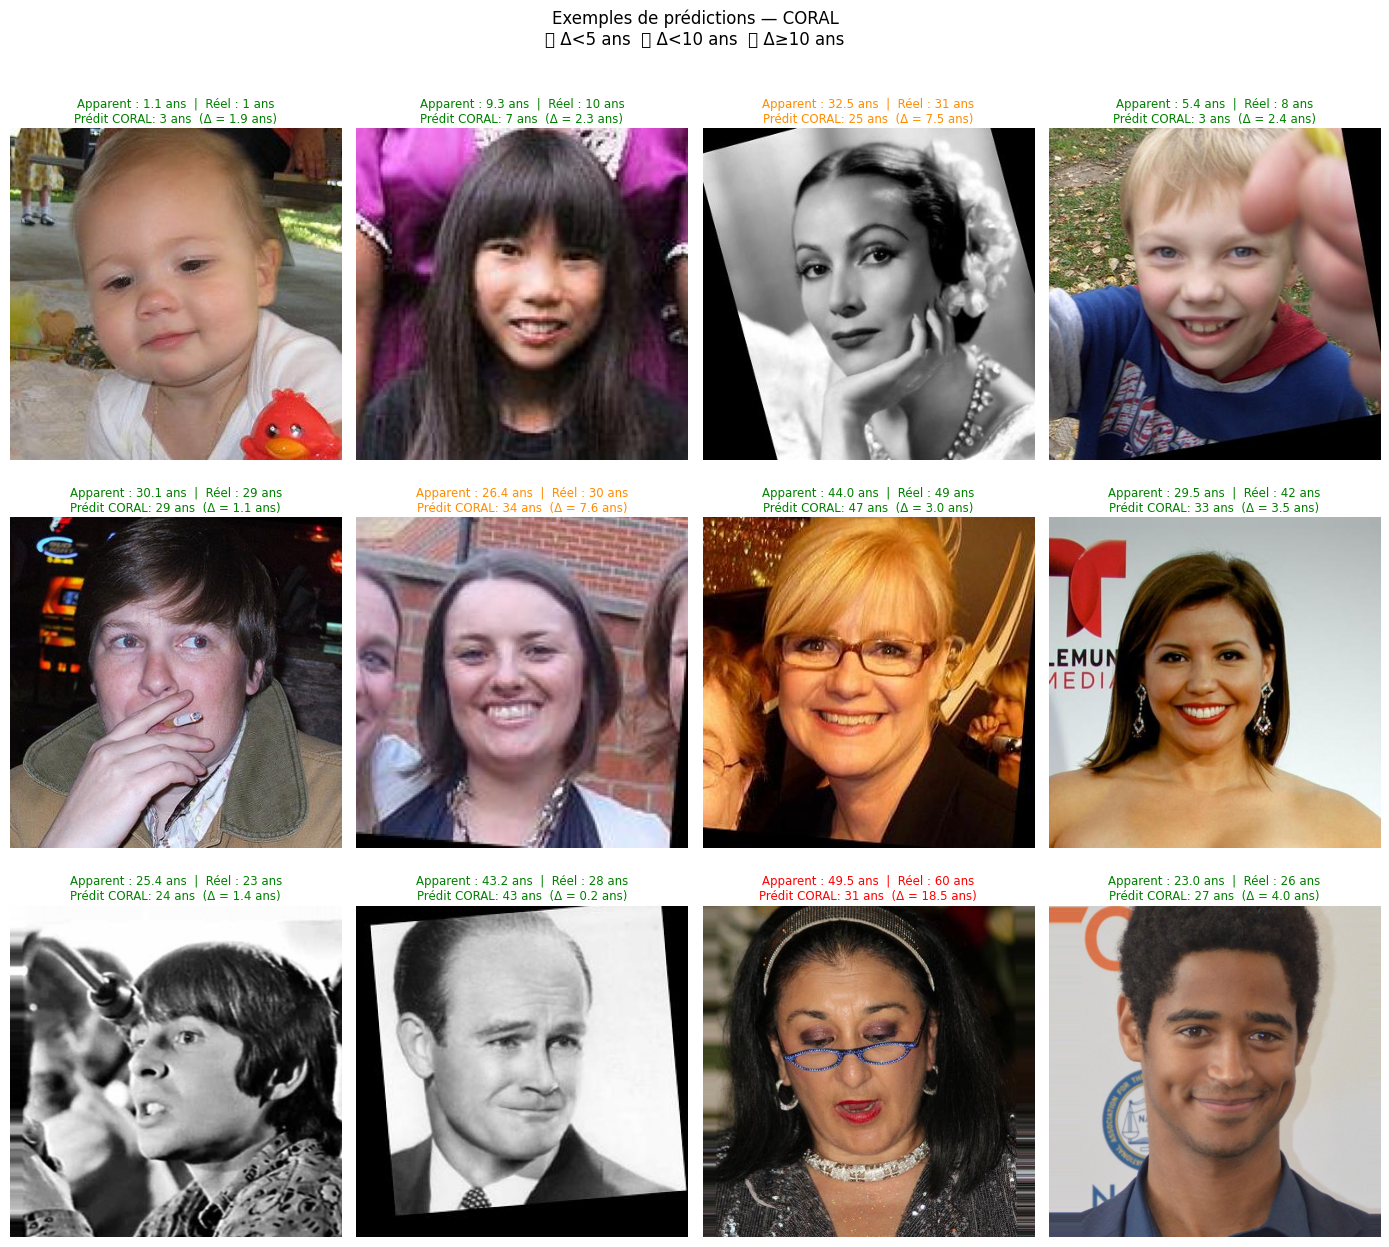

In [32]:
# ── Visualisation des prédictions CORAL sur des exemples test ────────────────
ckpt_coral = torch.load(CKPT_CORAL, map_location=device)
model_coral.load_state_dict(ckpt_coral["state_dict"])

N_SHOW  = min(12, len(test_ds_v2))
COLS    = min(4, N_SHOW)
ROWS    = math.ceil(N_SHOW / COLS)
indices = random.sample(range(len(test_ds_v2)), N_SHOW)

fig, axes = plt.subplots(ROWS, COLS, figsize=(COLS * 3.5, ROWS * 4.2))
axes_flat = np.array(axes).flatten()

model_coral.eval()
with torch.no_grad():
    for plot_i, idx in enumerate(indices):
        row       = test_ds_v2.df.iloc[idx]
        age_float = float(row[test_ds_v2.age_col])
        real_age  = float(row["real_age"]) if "real_age" in test_ds_v2.df.columns else age_float

        face_p   = test_ds_v2.img_dir / (row["file_name"] + "_face.jpg")
        full_p   = test_ds_v2.img_dir / row["file_name"]
        img_raw  = cv2.imread(str(face_p if face_p.exists() else full_p))
        if img_raw is not None:
            img_raw = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
        else:
            img_raw = np.zeros((224, 224, 3), dtype=np.uint8)

        img_tensor, *_ = test_ds_v2[idx]
        pred = model_coral.predict(img_tensor.unsqueeze(0).to(device)).item()
        err  = abs(pred - age_float)
        color = "green" if err < 5 else ("darkorange" if err < 10 else "red")

        axes_flat[plot_i].imshow(img_raw)
        axes_flat[plot_i].set_title(
            f"Apparent : {age_float:.1f} ans  |  Réel : {real_age:.0f} ans\n"
            f"Prédit CORAL: {pred:.0f} ans  (Δ = {err:.1f} ans)",
            fontsize=8.5, color=color, pad=4)
        axes_flat[plot_i].axis("off")

for ax in axes_flat[N_SHOW:]:
    ax.axis("off")

plt.suptitle("Exemples de prédictions — CORAL\n🟢 Δ<5 ans  🟠 Δ<10 ans  🔴 Δ≥10 ans",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [28]:
# ── Comparaison finale des 4 méthodes ─────────────────────────────────────────
# Évaluation test — MV
ckpt_mv = torch.load(CKPT_MV, map_location=device)
model_mv.load_state_dict(ckpt_mv["state_dict"])
model_mv.eval()
preds_mv, gt_mv = [], []
with torch.no_grad():
    for imgs, _, age_float, _, _ in test_loader_v2:
        preds_mv.extend(model_mv.predict(imgs.to(device)).cpu().numpy())
        gt_mv.extend(age_float.numpy())
mae_mv = np.abs(np.array(preds_mv) - np.array(gt_mv)).mean()

# Évaluation test — CORAL
ckpt_coral = torch.load(CKPT_CORAL, map_location=device)
model_coral.load_state_dict(ckpt_coral["state_dict"])
model_coral.eval()
preds_coral, gt_coral = [], []
with torch.no_grad():
    for imgs, _, age_float, _, _ in test_loader_v2:
        preds_coral.extend(model_coral.predict(imgs.to(device)).cpu().numpy())
        gt_coral.extend(age_float.numpy())
mae_coral = np.abs(np.array(preds_coral) - np.array(gt_coral)).mean()

# Résumé
methods = ["Label Smoothing σ=1.5", "Label Smoothing σ=3.0", "MV Loss", "CORAL"]
maes    = [min(history_v1['val_mae']), min(history_v2['val_mae']), mae_mv, mae_coral]

print("\n══════════════════════════════════════════════════════════")
print("  Comparaison finale — MAE test (jeu de test APPA-real)")
print("══════════════════════════════════════════════════════════")
for m, mae in zip(methods, maes):
    bar = '█' * int(mae * 2)
    print(f"  {m:<25} : {mae:.2f} ans  {bar}")
print(f"  {'Humain (baseline)':<25} : 4.50 ans  {'█' * 9}")
print(f"  {'DEX VGG-16 (2016)':<25} : 6.52 ans  {'█' * 13}")
print("══════════════════════════════════════════════════════════")


══════════════════════════════════════════════════════════
  Comparaison finale — MAE test (jeu de test APPA-real)
══════════════════════════════════════════════════════════
  Label Smoothing σ=1.5     : 6.43 ans  ████████████
  Label Smoothing σ=3.0     : 5.73 ans  ███████████
  MV Loss                   : 6.79 ans  █████████████
  CORAL                     : 7.34 ans  ██████████████
  Humain (baseline)         : 4.50 ans  █████████
  DEX VGG-16 (2016)         : 6.52 ans  █████████████
══════════════════════════════════════════════════════════


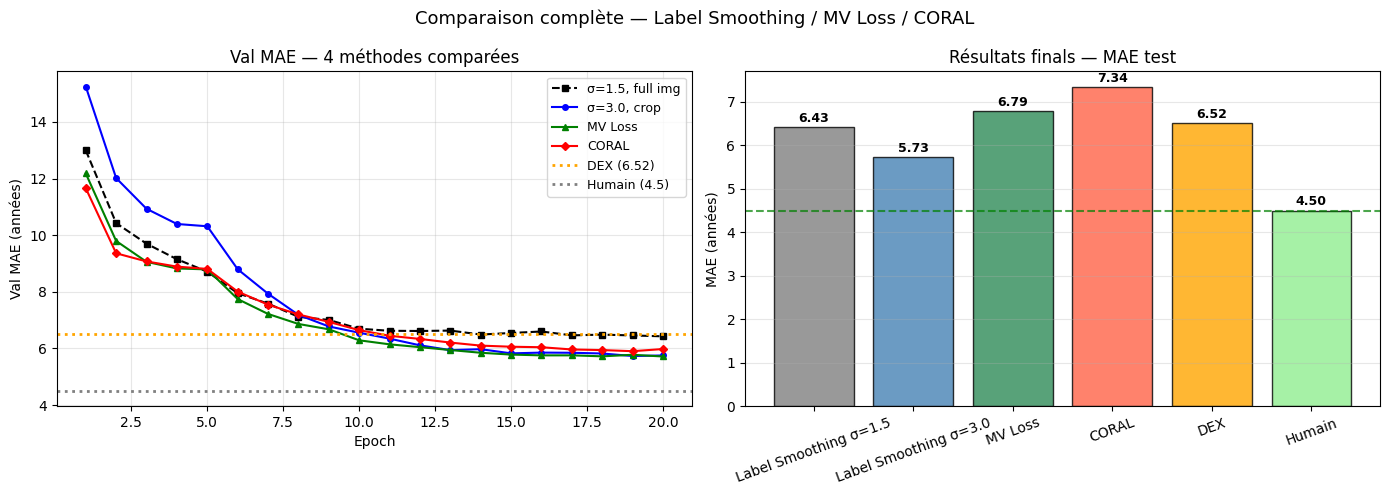

In [29]:
# ── Graphe comparatif — courbes val MAE des 4 méthodes ───────────────────────
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history_v1["val_mae"],    "k--s",  label="σ=1.5, full img",  markersize=4)
axes[0].plot(epochs, history_v2["val_mae"],    "b-o",   label="σ=3.0, crop",      markersize=4)
axes[0].plot(epochs, history_mv["val_mae"],    "g-^",   label="MV Loss",           markersize=4)
axes[0].plot(epochs, history_coral["val_mae"], "r-D",   label="CORAL",             markersize=4)
axes[0].axhline(y=6.52, color='orange', linestyle=':', linewidth=2, label='DEX (6.52)')
axes[0].axhline(y=4.50, color='gray',   linestyle=':', linewidth=2, label='Humain (4.5)')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Val MAE (années)")
axes[0].set_title("Val MAE — 4 méthodes comparées")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# Bar chart final
bars = axes[1].bar(methods + ["DEX", "Humain"],
                   maes    + [6.52,  4.50],
                   color=["gray", "steelblue", "seagreen", "tomato", "orange", "lightgreen"],
                   edgecolor="black", alpha=0.8)
for bar, mae in zip(bars, maes + [6.52, 4.50]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 f"{mae:.2f}", ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].axhline(y=4.50, color='green', linestyle='--', linewidth=1.5, alpha=0.7)
axes[1].set_ylabel("MAE (années)"); axes[1].set_title("Résultats finals — MAE test")
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle("Comparaison complète — Label Smoothing / MV Loss / CORAL", fontsize=13)
plt.tight_layout()
plt.savefig('comparison_all_methods.png', dpi=120, bbox_inches='tight')
plt.show()